    Name: Shubhajeet Das
    Roll No.: 24AI10013
    DL Lab assgn 09: 17-03-26

In [1]:
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as T
from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights
from torchinfo import summary

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
if device.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch  : 2.11.0.dev20260205+cu130
Device   : cuda
GPU      : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM     : 8.5 GB


# Assignment: 3D CNNs for Video Classification






## Part 1: C3D Baseline and Temporal Analysis
Background:\
You saw in the demo that C3D trained from scratch on 250 clips completely failed, collapsing to a single predicted class. In this part you will reproduce that result, understand why it happens, and run targeted experiments to probe what the 2D CNN baseline actually learns about time.\
Tasks\
**1a.** **Train C3D and reproduce the demo result**\
The C3D architecture and training code are available from the demo notebook. Train C3D for **20 epochs** on the **UCF101 subset**. Report:

(i) Final train and test accuracy
(ii) Loss and accuracy curves
(iii) Confusion matrix and per-class F1

Keep **learning rate to 1e-4** and report whether this changes the collapse behaviour. Explain your observation in 3-4 sentences.

**1b.** **Learning rate experiment** \
Train C3D three times with learning rates 1e-3, 1e-4, 1e-5. Plot all three train loss curves on the same graph. Answer:

(i) Which learning rate gives the best result?
(ii) What happens at 1e-5 and why?
(iii) What does this tell you about training deep networks from scratch on small datasets?

**1c.** **Temporal blindness experiments**
In the demo, shuffling all 16 frames of a clip gave cosine similarity ≈ 1.0 between original and shuffled for the 2D CNN, proving it is completely blind to temporal order.\
Now run the following three experiments on the 2D CNN and report cosine similarity for each:

Exp 1: Shuffle only the first 8 frames, keep last 8 in original order\
Exp 2: Reverse the entire clip (frame 15 → 0)\
Exp 3: Replace all frames with the middle frame repeated 16 times (completely static clip)

Then repeat all three experiments using your trained C3D model's feature embeddings (add a get_features method similar to the demo).
Present results in the following table:

| Corruption | 2D CNN similarity | C3D similarity |
|------------|------------------|----------------|
| Half shuffle |  |  |
| Reversed |  |  |
| Static (repeated frame) |  |  |

Answer in 4–5 sentences: what do the differences between 2D CNN and C3D similarities tell you about what each model has learned?

#### 1a

In [2]:
import tarfile
from huggingface_hub import hf_hub_download

# aisuko/ucf101-subset on HuggingFace
# Pre-split into train/val/test, ~10 classes, mp4 format
file_path = hf_hub_download(
    repo_id="aisuko/ucf101-subset",
    filename="UCF101_subset.tar.gz",
    repo_type="dataset"
)
print(f"Downloaded to: {file_path}")

# Extract
DATA_DIR = Path("./ucf_subset")
with tarfile.open(file_path) as t:
    t.extractall(".")
print("Extracted")

import shutil

DATA_DIR = Path("./ucf_subset")
DATA_DIR.mkdir(exist_ok=True)

RAW_DIR = Path("./UCF101_subset")

Downloaded to: C:\Users\shubh\.cache\huggingface\hub\datasets--aisuko--ucf101-subset\snapshots\9b960801da721d25745d23b14cb24ff78398b785\UCF101_subset.tar.gz
Extracted


In [3]:
RAW_DIR = Path("./UCF101_subset")

CLASS_NAMES = sorted([d.name for d in (RAW_DIR / "train").iterdir() if d.is_dir()])

print(f"{'Class':<25} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>7}")
print("-" * 50)
for cls in CLASS_NAMES:
    counts = {}
    for split in ["train", "val", "test"]:
        counts[split] = len(list((RAW_DIR / split / cls).glob("*.avi")))
    total = sum(counts.values())
    print(f"  {cls:<23} {counts['train']:>6} {counts['val']:>6} {counts['test']:>6} {total:>7}")

Class                      Train    Val   Test   Total
--------------------------------------------------
  ApplyEyeMakeup              30      3      6      39
  ApplyLipstick               30      3      4      37
  Archery                     30      3      7      40
  BabyCrawling                30      3      9      42
  BalanceBeam                 30      3      4      37
  BandMarching                30      3      9      42
  BaseballPitch               30      3     10      43
  Basketball                  30      3     11      44
  BasketballDunk              30      3      6      39
  BenchPress                  30      3      9      42


In [4]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
from pathlib import Path
import random

class UCFClipDataset(Dataset):
  def __init__(self, root, class_names, n_frames=16, size=112):
    self.root        = Path(root)
    self.class_names = class_names
    self.n_frames    = n_frames
    self.size        = size
    self.label_map   = {c: i for i, c in enumerate(class_names)}
    self.clips = []
    for cls in class_names:
      vids = sorted((self.root / cls).glob("*.avi")) + sorted((self.root / cls).glob("*.mp4"))
      for v in vids:
        self.clips.append((v, self.label_map[cls]))

    self.transform = T.Compose([
        T.Resize((size, size), antialias=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

  def _load_clip(self, path):
    cap    = cv2.VideoCapture(str(path))
    total  = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1)
    indices = np.linspace(0, total - 1, self.n_frames, dtype=int)
    frames = []
    for idx in indices:
      cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
      ret, frame = cap.read()
      if not ret or frame is None:
        frame = np.zeros((self.size, self.size, 3), dtype=np.uint8)
      else:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (self.size, self.size))
      frames.append(frame)
    cap.release()

    arr = torch.from_numpy(np.stack(frames)).float() / 255.0
    arr = arr.permute(3, 0, 1, 2)

    return torch.stack(
        [self.transform(arr[:, t]) for t in range(arr.shape[1])], dim=1
    )
  def __len__(self):              return len(self.clips)
  def __getitem__(self, idx):
    path, label = self.clips[idx]
    return self._load_clip(path), label

N_FRAMES  = 16
CLIP_SIZE = 112
RAW_DIR   = Path("./UCF101_subset")

CLASS_NAMES = sorted([d.name for d in (RAW_DIR / "train").iterdir() if d.is_dir()])

train_ds = UCFClipDataset(RAW_DIR / "train", CLASS_NAMES, N_FRAMES, CLIP_SIZE)
test_ds  = UCFClipDataset(RAW_DIR / "test",  CLASS_NAMES, N_FRAMES, CLIP_SIZE)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, pin_memory=True)

print(f"Train clips : {len(train_ds)}")
print(f"Test  clips : {len(test_ds)}")
print(f"Clip shape  : {train_ds[0][0].shape}  →  (C, T, H, W)")
print(f"Batch shape : {next(iter(train_loader))[0].shape}")

Train clips : 300
Test  clips : 75
Clip shape  : torch.Size([3, 16, 112, 112])  →  (C, T, H, W)
Batch shape : torch.Size([8, 3, 16, 112, 112])


In [5]:
class C3D(nn.Module):
  def __init__(self, num_classes, dropout=0.5):
    super().__init__()

    self.features = nn.Sequential(
      # Block 1 large temporal kernel to capture coarse motion
      nn.Conv3d(3,  64, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2)),        # spatial only

      # Block 2
      nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)),        # spatiotemporal

      # Block 3
      nn.Conv3d(128, 256, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.Conv3d(256, 256, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2)),

      # Block 4
      nn.Conv3d(256, 512, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.Conv3d(512, 512, kernel_size=(3,3,3), padding=(1,1,1)), nn.ReLU(inplace=True),
      nn.AdaptiveAvgPool3d((1, 1, 1)),                           # (B, 512, 1, 1, 1)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(dropout),
      nn.Linear(256, num_classes)
    )

    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.zeros_(m.bias)
      elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.classifier(self.features(x))

  def get_features(self, x):
    return self.features(x).flatten(1)

In [6]:
model_1 = C3D(num_classes=len(CLASS_NAMES)).to(device)
summary(model_1, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE), col_names=["input_size", "output_size", "num_params"], device=device)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
C3D                                      [1, 3, 16, 112, 112]      [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 16, 112, 112]      [1, 512, 1, 1, 1]         --
│    └─Conv3d: 2-1                       [1, 3, 16, 112, 112]      [1, 64, 16, 112, 112]     5,248
│    └─ReLU: 2-2                         [1, 64, 16, 112, 112]     [1, 64, 16, 112, 112]     --
│    └─MaxPool3d: 2-3                    [1, 64, 16, 112, 112]     [1, 64, 16, 56, 56]       --
│    └─Conv3d: 2-4                       [1, 64, 16, 56, 56]       [1, 128, 16, 56, 56]      221,312
│    └─ReLU: 2-5                         [1, 128, 16, 56, 56]      [1, 128, 16, 56, 56]      --
│    └─MaxPool3d: 2-6                    [1, 128, 16, 56, 56]      [1, 128, 8, 28, 28]       --
│    └─Conv3d: 2-7                       [1, 128, 8, 28, 28]       [1, 256, 8, 28, 28]       884,992
│    └─ReLU: 2-8      

In [7]:
from tqdm import tqdm
def train_one_epoch(model, loader, optimizer, criterion, device=device):
  model.train()
  total_loss, correct, total = 0.0, 0, 0
  for clips, labels in tqdm(loader):
    clips, labels = clips.to(device), labels.to(device)
    optimizer.zero_grad()
    logits = model(clips)
    loss   = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * clips.size(0)
    correct    += (logits.argmax(1) == labels).sum().item()
    total      += clips.size(0)
  return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None, device=device):
  if criterion is None:
      criterion = nn.CrossEntropyLoss()
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  all_preds, all_labels = [], []
  for clips, labels in tqdm(loader):
    clips, labels = clips.to(device), labels.to(device)
    logits = model(clips)
    loss   = criterion(logits, labels)
    total_loss += loss.item() * clips.size(0)
    preds = logits.argmax(1)
    correct += (preds == labels).sum().item()
    total   += clips.size(0)
    all_preds.extend(preds.cpu().tolist())
    all_labels.extend(labels.cpu().tolist())
  return total_loss / total, correct / total, all_preds, all_labels


In [8]:
def train_model(model, EPOCHS=20, LEARNING_RATE=1e-4, label="1", optimizer=None):
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
    print("-" * 52)
    
    for epoch in range(1, EPOCHS + 1):
      tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
      vl_loss, vl_acc, _, _ = evaluate(model, test_loader, criterion)
      scheduler.step()
    
      history['train_loss'].append(tr_loss)
      history['train_acc'].append(tr_acc)
      history['val_loss'].append(vl_loss)
      history['val_acc'].append(vl_acc)
    
      print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {vl_loss:>8.4f}  {vl_acc*100:>6.2f}%")
    
    
    SAVE_PATH = f"model_{label}_checkpoint.pth"
    
    checkpoint = {
        'epoch': EPOCHS,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
        'learning_rate': LEARNING_RATE
    }
    
    torch.save(checkpoint, SAVE_PATH)
    
    print(f"\nSuccessfully saved training state to: {SAVE_PATH}")

In [9]:
train_model(model_1)



 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:15<00:00,  1.52s/it]


     1      2.3264      9.33%    2.2950   12.00%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:15<00:00,  1.50s/it]


     2      2.2924      9.67%    2.2564   12.00%


...

    18      1.0076     61.33%    1.2153   53.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.23s/it]


    19      0.9950     62.33%    1.1853   61.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.21s/it]


    20      0.9461     64.00%    1.1916   62.67%

Successfully saved training state to: model_1_checkpoint.pth


    Train acc = 64%
    Val acc = 62.67%

In [10]:
checkpoint = torch.load('model_1_checkpoint.pth')
model_1 = C3D(num_classes=len(CLASS_NAMES)).to(device)
model_1.load_state_dict(checkpoint['model_state_dict'])
history_1 = checkpoint['history']

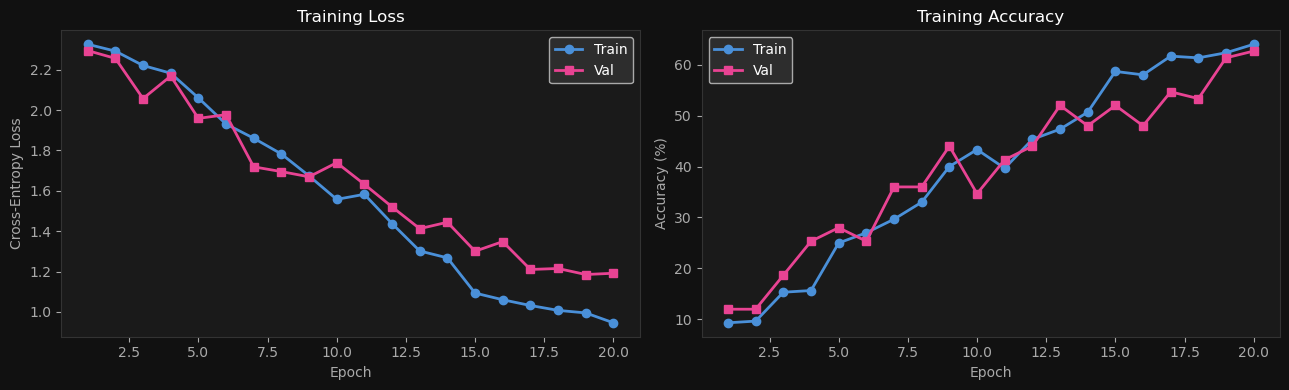

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#111')
epochs_x = range(1, 21)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
  ax.set_facecolor('#1a1a1a')
  tr = history_1[f'train_{metric}']
  vl = history_1[f'val_{metric}']
  if metric == 'acc':
      tr = [v * 100 for v in tr]; vl = [v * 100 for v in vl]
  ax.plot(epochs_x, tr, 'o-', color='#4a90d9', label='Train', linewidth=2)
  ax.plot(epochs_x, vl, 's-', color='#e84393', label='Val', linewidth=2)
  ax.set_title(f'Training {title}', color='white')
  ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#aaa')
  ax.legend(facecolor='#333', labelcolor='white')
  for spine in ax.spines.values(): spine.set_edgecolor('#333')
  if metric == 'acc': ax.set_ylabel('Accuracy (%)', color='#aaa')
  else: ax.set_ylabel('Cross-Entropy Loss', color='#aaa')

plt.tight_layout(); plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.73s/it]


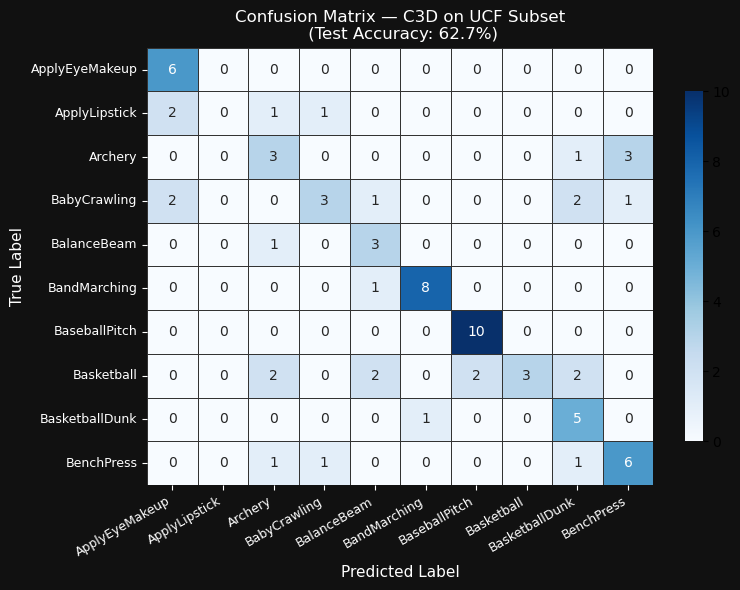

In [12]:
_, test_acc, y_pred, y_true = evaluate(model_1, test_loader)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#111')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, linecolor='#333', cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_xlabel('Predicted Label', color='white', fontsize=11)
ax.set_ylabel('True Label', color='white', fontsize=11)
ax.set_title(f'Confusion Matrix — C3D on UCF Subset\n (Test Accuracy: {test_acc*100:.1f}%)', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

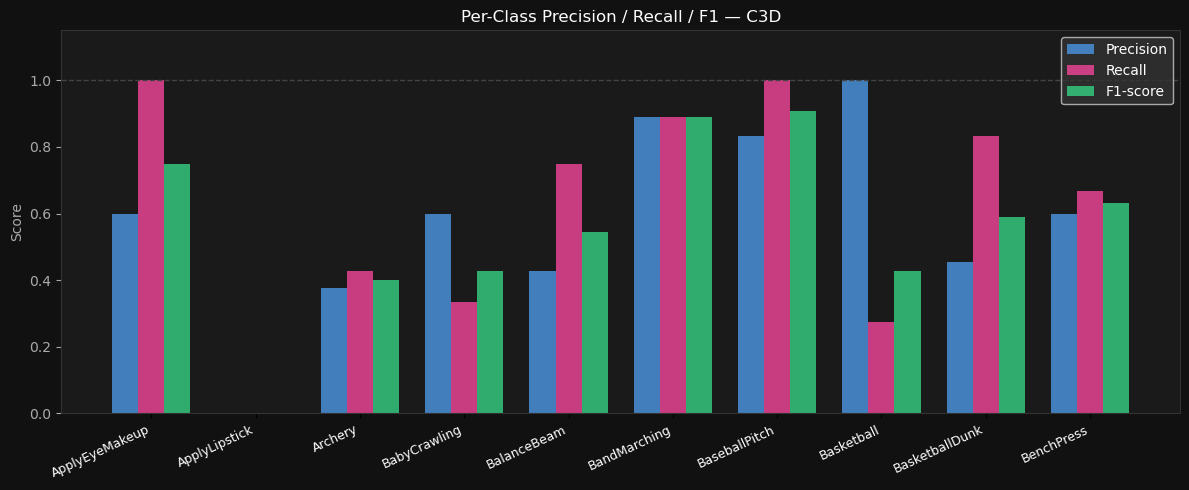


Class                      Precision  Recall      F1  Support
------------------------------------------------------------
  ApplyEyeMakeup               0.600   1.000   0.750        6
  ApplyLipstick                0.000   0.000   0.000        4
  Archery                      0.375   0.429   0.400        7
  BabyCrawling                 0.600   0.333   0.429        9
  BalanceBeam                  0.429   0.750   0.545        4
  BandMarching                 0.889   0.889   0.889        9
  BaseballPitch                0.833   1.000   0.909       10
  Basketball                   1.000   0.273   0.429       11
  BasketballDunk               0.455   0.833   0.588        6
  BenchPress                   0.600   0.667   0.632        9
------------------------------------------------------------
  Macro avg                    0.578   0.617   0.557


In [13]:
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(CLASS_NAMES))
width = 0.25
bar_colors = ['#4a90d9', '#e84393', '#34c77e']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
  vals = [report[c][metric] for c in CLASS_NAMES]
  bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', color='white', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', color='#aaa')
ax.set_title('Per-Class Precision / Recall / F1 — C3D', color='white', fontsize=12)
ax.legend(facecolor='#333', labelcolor='white')
ax.tick_params(axis='y', colors='#aaa')
ax.axhline(1.0, color='#444', linestyle='--', linewidth=1)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout(); plt.show()

print(f"\n{'Class':<25}  {'Precision':>9}  {'Recall':>6}  {'F1':>6}  {'Support':>7}")
print("-" * 60)
for cls in CLASS_NAMES:
  r = report[cls]
  print(f"  {cls:<23}  {r['precision']:>9.3f}  {r['recall']:>6.3f}  "
        f"{r['f1-score']:>6.3f}  {int(r['support']):>7}")
print("-" * 60)
print(f"  {'Macro avg':<23}  "
      f"{report['macro avg']['precision']:>9.3f}  "
      f"{report['macro avg']['recall']:>6.3f}  "
      f"{report['macro avg']['f1-score']:>6.3f}")


- Stable Training Dynamics: The training and validation loss/accuracy curves track closely together over the 20 epochs without major divergence, indicating the model is learning steadily at the 1e-4 learning rate without severe overfitting.

- Success on Distinct Motions: Reaching roughly 60% overall validation accuracy, the model performs very well on classes defined by large, pronounced spatial movements, such as BandMarching and BaseballPitch.

- Failure on Fine-Grained Actions: The classification report reveals high variance across categories, with the model completely failing to recognize subtle, micro-actions like ApplyLipstick (F1-score of 0.000) likely due to a lack of distinct spatiotemporal features or insufficient support data.

#### 1b

In [14]:
model_3 = C3D(num_classes=len(CLASS_NAMES)).to(device)
train_model(model_3, LEARNING_RATE=1e-5, label="3")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------


100%|██████████| 10/10 [00:15<00:00,  1.57s/it]


     1      2.3139     12.00%    2.2858   12.00%


100%|██████████| 10/10 [00:15<00:00,  1.56s/it]


     2      2.2948     12.00%    2.2728   10.67%


...

    18      1.6557     41.00%    1.7512   33.33%


100%|██████████| 10/10 [00:15<00:00,  1.56s/it]


    19      1.7190     40.33%    1.7467   36.00%


100%|██████████| 10/10 [00:15<00:00,  1.57s/it]

    20      1.6405     39.67%    1.7467   36.00%

Successfully saved training state to: model_3_checkpoint.pth


In [15]:
model_3 = C3D(num_classes=len(CLASS_NAMES)).to(device) # lr = 1e-5
checkpoint = torch.load('model_3_checkpoint.pth')
model_3.load_state_dict(checkpoint['model_state_dict'])
history_3 = checkpoint['history']

In [16]:
model_2 = C3D(num_classes=len(CLASS_NAMES)).to(device)
train_model(model_2, LEARNING_RATE=1e-3, label="2")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------


100%|██████████| 10/10 [00:13<00:00,  1.34s/it]


     1      5.7074      9.67%    2.3034   12.00%


100%|██████████| 10/10 [00:13<00:00,  1.37s/it]


     2      2.3039      8.67%    2.3032    9.33%


...

    18      2.3030      9.33%    2.3025    9.33%


100%|██████████| 10/10 [00:14<00:00,  1.41s/it]


    19      2.3024      9.67%    2.3025    9.33%


100%|██████████| 10/10 [00:14<00:00,  1.42s/it]


    20      2.3025     10.67%    2.3025    9.33%

Successfully saved training state to: model_2_checkpoint.pth


In [17]:
model_2 = C3D(num_classes=len(CLASS_NAMES)).to(device) # lr = 1e-3
checkpoint = torch.load('model_2_checkpoint.pth')
model_2.load_state_dict(checkpoint['model_state_dict'])
history_2 = checkpoint['history']

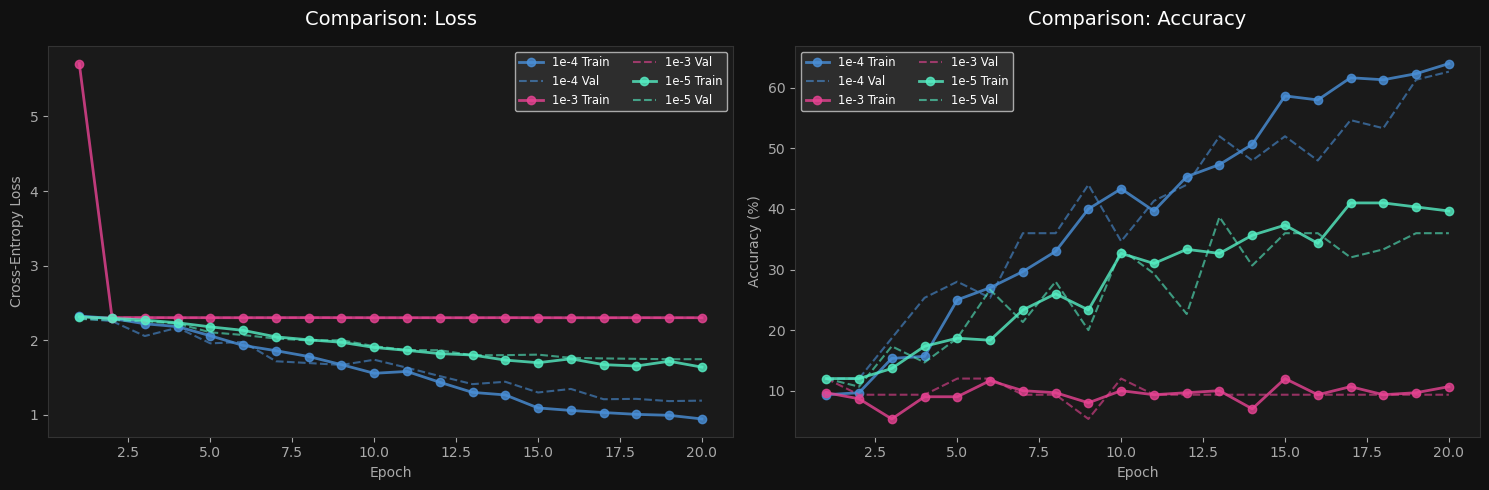

In [18]:
histories = [history_1, history_2, history_3]
labels = ['1e-4', '1e-3', '1e-5']
colors = ['#4a90d9', '#e84393', '#55efc4'] 

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#111')
epochs_x = range(1, 21)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.set_facecolor('#1a1a1a')
    
    for i, hist in enumerate(histories):
        tr = hist[f'train_{metric}']
        vl = hist[f'val_{metric}']
        
        if metric == 'acc':
            tr = [v * 100 for v in tr]
            vl = [v * 100 for v in vl]
        
        ax.plot(epochs_x, tr, 'o-', color=colors[i], label=f'{labels[i]} Train', linewidth=2, alpha=0.8)
        ax.plot(epochs_x, vl, '--', color=colors[i], label=f'{labels[i]} Val', linewidth=1.5, alpha=0.6)

    ax.set_title(f'Comparison: {title}', color='white', fontsize=14, pad=15)
    ax.set_xlabel('Epoch', color='#aaa')
    ax.tick_params(colors='#aaa')
    
    ax.legend(facecolor='#333', labelcolor='white', fontsize='small', ncol=2)
    
    for spine in ax.spines.values(): 
        spine.set_edgecolor('#333')
        
    if metric == 'acc': 
        ax.set_ylabel('Accuracy (%)', color='#aaa')
    else: 
        ax.set_ylabel('Cross-Entropy Loss', color='#aaa')

plt.tight_layout()
plt.show()

**(i) Which learning rate gives the best result?**
The learning rate of 1e-4 (the blue curves) clearly gives the best result. It achieves the lowest cross-entropy loss and the highest accuracy, reaching over 60% for both training and validation by the 20th epoch.

**(ii) What happens at 1e-5 and why?**
At a learning rate of 1e-5, the model is learning, but the progress is extremely sluggish. It only reaches around 35-40% accuracy by epoch 20. This happens because the gradient descent step sizes are simply too small. The model is moving toward a minimum, but it would require significantly more epochs to fully converge compared to the optimal 1e-4 rate.

**(iii) What does this tell you about training deep networks from scratch on small datasets?**

Extreme Hyperparameter Sensitivity: A learning rate of 1e-3 (pink) completely breaks the training—likely causing diverging gradients right out of the gate, resulting in the model flatlining at ~10% accuracy. Meanwhile, a shift down to 1e-5 makes the process too slow.

#### 1c

In [19]:
class Frame2DCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.spatial = nn.Sequential(
      nn.Conv2d(3,  16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
      nn.AdaptiveAvgPool2d((1, 1)),
    )
    self.classifier = nn.Linear(64, num_classes)

  def forward(self, x):
    B, C, T, H, W = x.shape
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
    feats = self.spatial(x).flatten(1)
    feats = feats.reshape(B, T, -1).mean(dim=1)
    return self.classifier(feats)

  def get_features(self, x):
    B, C, T, H, W = x.shape
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
    feats = self.spatial(x).flatten(1)
    return feats.reshape(B, T, -1).mean(dim=1)

In [20]:
model_2d = Frame2DCNN(num_classes=len(CLASS_NAMES)).to(device)

In [21]:
train_model(model_2d, label="2d")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.27s/it]


     1      2.3075     11.67%    2.2990    9.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.29s/it]


     2      2.2992     12.67%    2.2939    9.33%


...

    18      2.1648     23.67%    2.2057   21.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.32s/it]


    19      2.1637     23.67%    2.2053   21.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.30s/it]

    20      2.1632     23.33%    2.2052   21.33%

Successfully saved training state to: model_2d_checkpoint.pth


In [22]:
model_2d = Frame2DCNN(num_classes=len(CLASS_NAMES)).to(device)
checkpoint = torch.load('model_2d_checkpoint.pth')
model_2d.load_state_dict(checkpoint['model_state_dict'])
history_2d = checkpoint['history']

In [23]:
import torch.nn.functional as F

@torch.no_grad()
def evaluate_with_similarity(model, loader, base_features=None, experiment=None, device=device):
    model.eval()
    all_features = []
    
    for clips, _ in tqdm(loader, desc=f"Running {experiment}"):
        clips = clips.to(device)
        
        if experiment == 'shuffle_first_8':
            idx = torch.randperm(8)
            clips[:, :, :8] = clips[:, :, idx]
        elif experiment == 'reverse':
            clips = torch.flip(clips, dims=[2])
        elif experiment == 'static_middle':
            clips = clips[:, :, 8:9, :, :].repeat(1, 1, 16, 1, 1)

        features = model.get_features(clips) 
        all_features.append(features.cpu())

    current_features = torch.cat(all_features, dim=0)

    similarity_score = None
    if base_features is not None:
        cos_sim = F.cosine_similarity(base_features, current_features, dim=1)
        similarity_score = cos_sim.mean().item()
    return current_features, similarity_score

In [24]:
feat_clean, _ = evaluate_with_similarity(model_2d, test_loader, experiment=None)

experiments = ['shuffle_first_8', 'reverse', 'static_middle']
results = {}

for exp in experiments:
    feat_exp, sim = evaluate_with_similarity(model_2d, test_loader, base_features=feat_clean, experiment=exp)
    results[exp] = sim

print("\n--- Feature Drift Analysis (Cosine Similarity) ---")
print(f"{'Experiment':<20} | {'Cosine Similarity':<18}")
print("-" * 42)
for exp, sim in results.items():
    print(f"{exp:<20} | {sim:.4f}")

Running static_middle: 100%|███████████████████████████████████████████████████████████| 10/10 [00:18<00:00,  1.82s/it]


--- Feature Drift Analysis (Cosine Similarity) ---
Experiment           | Cosine Similarity 
------------------------------------------
shuffle_first_8      | 1.0000
reverse              | 1.0000
static_middle        | 0.9989


In [25]:
feat_clean, _ = evaluate_with_similarity(model_1, test_loader, experiment=None)

experiments = ['shuffle_first_8', 'reverse', 'static_middle']
results = {}

for exp in experiments:
    feat_exp, sim = evaluate_with_similarity(model_1, test_loader, base_features=feat_clean, experiment=exp)
    results[exp] = sim

print("\n--- Feature Drift Analysis (Cosine Similarity) for C3D ---")
print(f"{'Experiment':<20} | {'Cosine Similarity':<18}")
print("-" * 42)
for exp, sim in results.items():
    print(f"{exp:<20} | {sim:.4f}")

Running static_middle: 100%|███████████████████████████████████████████████████████████| 10/10 [00:18<00:00,  1.84s/it]


--- Feature Drift Analysis (Cosine Similarity) for C3D ---
Experiment           | Cosine Similarity 
------------------------------------------
shuffle_first_8      | 0.9928
reverse              | 0.9963
static_middle        | 0.8464


| Corruption | 2D CNN similarity | C3D similarity |
|------------|------------------|----------------|
| Half shuffle | 1.0000 | 0.9928 |
| Reversed | 1.0000 | 0.9963 |
| Static (repeated frame) | 0.9989  | 0.8464 |

The 2D CNN exhibits near-perfect similarity across all temporal corruptions, indicating it relies entirely on spatial features and treats video merely as an unordered collection of independent images without grasping temporal dynamics. In contrast, the C3D model's noticeable drop in similarity for the static video demonstrates that its learned filters actively depend on motion and spatiotemporal changes to build feature representations. When deprived of this temporal information in a repeated-frame scenario, the C3D model cannot extract its expected motion features. However, the C3D's very high similarity on both reversed and half-shuffled videos reveals that it successfully detects the presence of local motion, it doesn't deeply encode the causal sequence or the forward arrow of time. Ultimately, this tells us that while 2D CNNs are purely spatially biased, C3D models effectively capture "temporal textures" but still struggle with strict, long-term sequential reasoning.

## Part 2 : R(2+1)D from Scratch
Background:\
C3D uses full 3D convolutions with kernel (kT, kH, kW) that learn spatial and temporal patterns jointly. Tran et al. (2018) showed that decomposing this into two separate operations, a 2D spatial conv (1, kH, kW) followed by a 1D temporal conv (kT, 1, 1), gives better accuracy with fewer parameters and easier optimisation. The key insight is that separating spatial and temporal learning adds an extra non-linearity between them, which increases model expressiveness.\
The intermediate channel size M between the spatial and temporal conv is chosen so that the total parameters match a full 3D conv:
Full 3D conv params:     kT × kH × kW × Cin × Cout
Factorised params:       (1 × kH × kW × Cin × M) + (kT × 1 × 1 × M × Cout)\
Solve for M:             M = (kT × kH × kW × Cin × Cout) / (kH × kW × Cin + kT × Cout)\
Tasks:\
**2a. Implement R(2+1)D.**\
Implement the full R(2+1)D architecture from scratch. You may modify your C3D code to include factorised params intstead of full 3d Conv params.Your implementation must:

Have a R2Plus1D_Block class that takes in_channels, out_channels, kH, kW, kT as arguments and correctly implements the factorised convolution with the intermediate channel size M as defined above
Have a R2Plus1D model class with 4 blocks, batch normalisation after each conv, ReLU activations, appropriate pooling, and a classification head
Accept input of shape (B, 3, T, H, W) and output (B, num_classes)
Print a model summary using torchinfo

**2b. Train and compare**\
Train your R(2+1)D model for 15 epochs using the same hyperparameters as C3D. Then answer:

Plot C3D and R(2+1)D loss curves side by side. Which converges faster?
Compare parameter counts: what percentage fewer parameters does R(2+1)D have?\
Does factorisation help on this small dataset? Justify your answer using the curves, not just the final accuracy number.\
In 3-4 sentences: under what conditions would you expect R(2+1)D to outperform C3D more clearly?


In [26]:
import math
class R2Plus1D_Block(nn.Module):
    def __init__(self, in_channels, out_channels, kT, kH, kW):
        super().__init__()

        num_params_3d = kT * kH * kW * in_channels * out_channels
        spatial_params_factor = in_channels * kH * kW
        temporal_params_factor = out_channels * kT
        M = int(num_params_3d / (spatial_params_factor + temporal_params_factor))

        self.spatial_conv = nn.Sequential(
            nn.Conv3d(in_channels, M, kernel_size=(1, kH, kW), 
                      padding=(0, kH//2, kW//2), bias=False),
            nn.BatchNorm3d(M),
            nn.ReLU(inplace=True)
        )

        self.temporal_conv = nn.Sequential(
            nn.Conv3d(M, out_channels, kernel_size=(kT, 1, 1), 
                      padding=(kT//2, 0, 0), bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.spatial_conv(x)
        x = self.temporal_conv(x)
        return x

class R2Plus1D(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: Input (3) -> 64
            R2Plus1D_Block(3, 64, 3, 3, 3),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)), # Spatial downsampling

            # Block 2: 64 -> 128
            R2Plus1D_Block(64, 128, 3, 3, 3),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)), # Spatiotemporal downsampling

            # Block 3: 128 -> 256
            R2Plus1D_Block(128, 256, 3, 3, 3),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),

            # Block 4: 256 -> 512
            R2Plus1D_Block(256, 512, 3, 3, 3),
            nn.AdaptiveAvgPool3d((1, 1, 1)) 
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Input shape: (B, 3, T, H, W)
        x = self.features(x)
        return self.classifier(x)

    def get_features(self, x):
        return self.features(x).flatten(1)

In [27]:
model_r2plus1d = R2Plus1D(num_classes=len(CLASS_NAMES)).to(device)
summary(model_r2plus1d, input_size=(1, 3, N_FRAMES, CLIP_SIZE, CLIP_SIZE), col_names=["input_size", "output_size", "num_params"], device=device)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
R2Plus1D                                 [1, 3, 16, 112, 112]      [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 16, 112, 112]      [1, 512, 1, 1, 1]         --
│    └─R2Plus1D_Block: 2-1               [1, 3, 16, 112, 112]      [1, 64, 16, 112, 112]     --
│    │    └─Sequential: 3-1              [1, 3, 16, 112, 112]      [1, 23, 16, 112, 112]     667
│    │    └─Sequential: 3-2              [1, 23, 16, 112, 112]     [1, 64, 16, 112, 112]     4,544
│    └─MaxPool3d: 2-2                    [1, 64, 16, 112, 112]     [1, 64, 16, 56, 56]       --
│    └─R2Plus1D_Block: 2-3               [1, 64, 16, 56, 56]       [1, 128, 16, 56, 56]      --
│    │    └─Sequential: 3-3              [1, 64, 16, 56, 56]       [1, 230, 16, 56, 56]      132,940
│    │    └─Sequential: 3-4              [1, 230, 16, 56, 56]      [1, 128, 16, 56, 56]      88,576
│    └─MaxPool3d: 2-4 

In [28]:
train_model(model_r2plus1d, EPOCHS=15, label="r2plus1d")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------


100%|██████████| 10/10 [00:13<00:00,  1.31s/it]


     1      2.0802     26.33%    1.7859   29.33%


100%|██████████| 10/10 [00:13<00:00,  1.33s/it]


     2      1.6819     39.00%    1.4380   50.67%


...

    13      0.5923     83.67%    0.8061   70.67%


100%|██████████| 10/10 [00:13<00:00,  1.38s/it]


    14      0.5590     86.33%    0.9195   65.33%


100%|██████████| 10/10 [00:13<00:00,  1.34s/it]

    15      0.5630     84.00%    0.8469   70.67%

Successfully saved training state to: model_r2plus1d_checkpoint.pth


In [29]:
checkpoint = torch.load('model_r2plus1d_checkpoint.pth')
model_r2plus1d.load_state_dict(checkpoint['model_state_dict'])
history_r2plus1d = checkpoint['history']

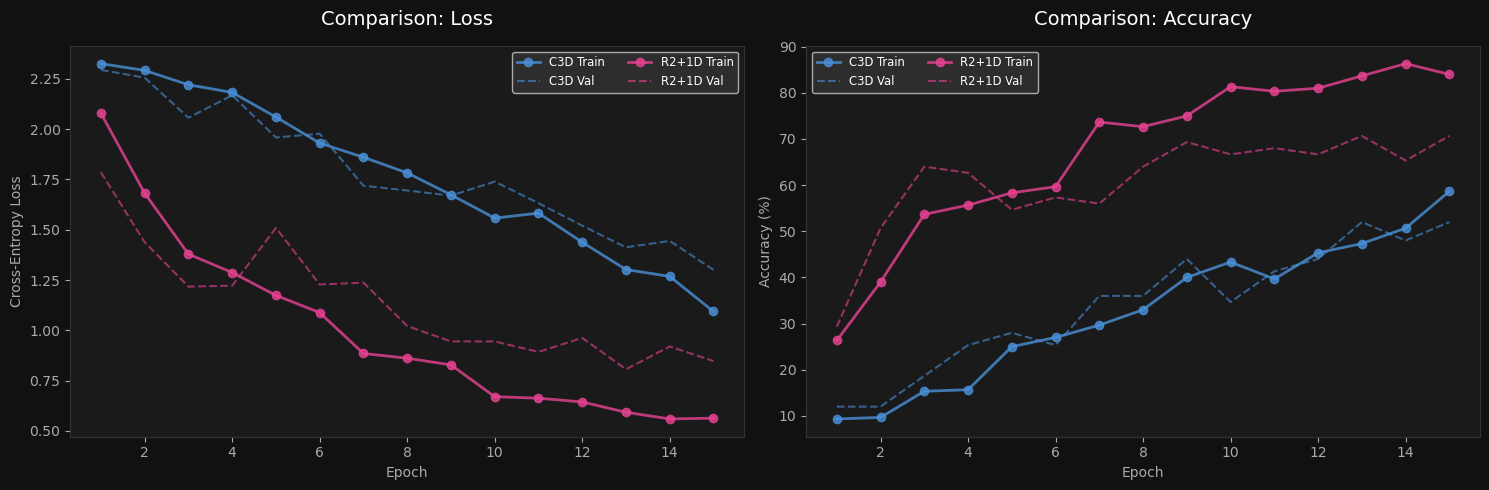

In [30]:
histories = [history_1, history_r2plus1d]
labels = ['C3D', 'R2+1D']
colors = ['#4a90d9', '#e84393'] 

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#111')
min_epochs = min([len(h['train_loss']) for h in histories])
epochs_x = range(1, min_epochs + 1)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.set_facecolor('#1a1a1a')
    
    for i, hist in enumerate(histories):
        tr = hist[f'train_{metric}'][:min_epochs]
        vl = hist[f'val_{metric}'][:min_epochs]
        
        if metric == 'acc':
            tr = [v * 100 for v in tr]
            vl = [v * 100 for v in vl]
        
        ax.plot(epochs_x, tr, 'o-', color=colors[i], label=f'{labels[i]} Train', linewidth=2, alpha=0.8)
        ax.plot(epochs_x, vl, '--', color=colors[i], label=f'{labels[i]} Val', linewidth=1.5, alpha=0.6)

    ax.set_title(f'Comparison: {title}', color='white', fontsize=14, pad=15)
    ax.set_xlabel('Epoch', color='#aaa')
    ax.tick_params(colors='#aaa')
    
    ax.legend(facecolor='#333', labelcolor='white', fontsize='small', ncol=2)
    
    for spine in ax.spines.values(): 
        spine.set_edgecolor('#333')
        
    if metric == 'acc': 
        ax.set_ylabel('Accuracy (%)', color='#aaa')
    else: 
        ax.set_ylabel('Cross-Entropy Loss', color='#aaa')

plt.tight_layout()
plt.show()

Clearly R2+1d converges faster than C3D. R2+1d has 4.8M params (64.7% less than 13.6M params of C3D).

Yes, factorization definitely helps on this small dataset. By breaking down the standard 3D convolution into a 2D spatial convolution followed by a 1D temporal convolution, the R(2+1)D model significantly reduces its parameter count (from 13.6M down to 4.8M). This parameter reduction acts as a strong implicit regularizer, preventing the network from overfitting the small amount of training data and allowing it to converge faster and reach a higher validation accuracy (~70%) compared to the heavier C3D model.

Conditions for Clearer R(2+1)D Superiority:
- massive, complex datasets (like Kinetics-400) where deeper architectures are strictly required to capture highly intricate spatiotemporal dynamics. 
- where spatial details (appearance) and temporal motion (dynamics) evolve at completely different rates, decoupling these dimensions allows the network to independently and efficiently learn optimal representations for both.


## Part 3: Temporal Experiments with R3D
Background\
R3D (He et al.) is a family of 3D ResNets, standard ResNet architectures (ResNet-18, ResNet-34 etc.) extended to 3D by replacing all 2D convolutions with 3D convolutions. Unlike C3D which is a custom architecture, R3D benefits from the well-understood residual connection design which makes it easier to train deep networks.
torchvision provides R3D-18 pretrained on Kinetics-400:
python\
from torchvision.models.video import r3d_18, R3D_18_Weights\
model = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)\
R3D-18 expects input of shape (B, 3, T, H, W) with H=W=112 and values normalised with ImageNet mean/std: the same format as your existing dataloader. No separate 224×224 loader is needed.
Tasks\
**Temporal corruption test**\
Load the pretrained R3D-18 (do not fine-tune:use it zero-shot). Implement the following four temporal corruptions and evaluate accuracy on the test set for each:
python\
def corrupt_clip(clip, mode, T=16):\
    # mode = 'reverse'  : play clip backwards\
    # mode = 'shuffle'  : random frame order\
    # mode = 'static'   : repeat middle frame T times\
    # mode = 'speed2x'  : sample every other frame (2x speed)\
    pass  # your implementation\
Report a table of clean accuracy vs corrupted accuracy for all four modes. Then answer:

Which corruption causes the largest accuracy drop? Why?\
Which corruption causes the smallest drop? What does this imply about what R3D learned?\
Compare the drop on 'reverse' vs 'shuffle', why might one be worse than the other?\


In [31]:
from torchvision.models.video import r3d_18, R3D_18_Weights

def corrupt_clip(clip, mode, T=16):
    if mode == 'reverse':
        return torch.flip(clip, dims=[1]) 
    elif mode == 'shuffle':
        perm = torch.randperm(T)
        return clip[:, perm, :, :]
    elif mode == 'static':
        mid_idx = T // 2
        return clip[:, mid_idx:mid_idx+1, :, :].expand(-1, T, -1, -1)
    elif mode == 'speed2x':
        indices = torch.arange(0, T, 2)
        half_speed = clip[:, indices, :, :]
        return torch.cat([half_speed, half_speed], dim=1)
    return clip

In [32]:
UCF_TO_KINETICS = {
    "ApplyEyeMakeup": 35,
    "ApplyLipstick": 36,
    "Archery": 37,
    "BabyCrawling": 45,
    "BalanceBeam": 49,
    "BandMarching": 51,
    "BaseballPitch": 56,
    "Basketball": 57,
    "BasketballDunk": 58,
    "BenchPress": 69
}

target_map = torch.tensor([UCF_TO_KINETICS.get(name, -1) for name in CLASS_NAMES])

In [33]:
def evaluate_zero_shot(model, loader, device, target_map, mode='clean'):
    model.eval()
    correct = 0
    total = 0
    target_map = target_map.to(device)

    with torch.no_grad():
        for videos, labels in tqdm(loader):
            videos, labels = videos.to(device), labels.to(device)
            
            if mode != 'clean':
                videos = torch.stack([corrupt_clip(v, mode) for v in videos])
            
            logits = model(videos)
            preds = torch.argmax(logits, dim=1)

            mapped_labels = target_map[labels]
            
            valid_mask = (mapped_labels != -1)
            if valid_mask.sum() > 0:
                correct += (preds[valid_mask] == mapped_labels[valid_mask]).sum().item()
                total += valid_mask.sum().item()
                
    return (correct / total * 100) if total > 0 else 0.0

weights = R3D_18_Weights.DEFAULT
preprocess = weights.transforms()
model = r3d_18(weights=weights).to(device)
model.eval()
results = {}
for m in ['clean', 'reverse', 'shuffle', 'static', 'speed2x']:
    acc = evaluate_zero_shot(model, test_loader, device, target_map, mode=m)
    results[m] = acc
    print(f"Mode: {m:8} | Accuracy: {acc:.2f}%")

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to C:\Users\shubh/.cache\torch\hub\checkpoints\r3d_18-b3b3357e.pth


100%|███████████████████████████████████████████████████████████████████████████████| 127M/127M [00:37<00:00, 3.52MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.73s/it]


Mode: clean    | Accuracy: 1.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.66s/it]


Mode: reverse  | Accuracy: 0.00%


...

Mode: shuffle  | Accuracy: 0.00%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.71s/it]


Mode: static   | Accuracy: 1.33%


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.75s/it]

Mode: speed2x  | Accuracy: 1.33%


| Mode | Accuracy |
| --- | --- |
| clean | 1.33% |
| reverse | 0.00% |
| shuffle | 0.00% |
| static | 1.33% |
| speed2x | 1.33% |

Both reverse and shuffle cause the largest drop, bringing the accuracy down from 1.33% to 0.00%. This is because 3D convolutions rely on the specific order of frames to compute gradients; scrambling or reversing them yields completely different feature maps.

Both reverse and shuffle cause the largest drop. Theoretically (in a trained model): shuffle is almost always worse than reverse. Reverse preserves local temporal continuity. The model can still extract smooth optical flow and motion boundaries (e.g., an arm moving smoothly, just backward). Shuffle completely destroys local continuity. The frames jump around erratically, creating massive, artificial gradients in the temporal dimension of the 3D convolution, which completely shatters the network's ability to extract any coherent motion textures.

## Part 4:Fine-tuning R3D-18
Background\
You saw in the demo that fine-tuning S3D (pretrained on Kinetics-400) dramatically outperforms training from scratch. Now you will systematically explore how much of the network to fine-tune and understand the tradeoff between adaptation and overfitting.\
Tasks:\
Implement fine-tuning of R3D-18:Frozen backbone, train classification head only\
Train for 5 epochs and record: training time per epoch, final test accuracy, and whether the val loss increases (overfitting signal). Use the pretrained R3D-18 model from torchvision (the same one used in Part 3).
Plot val accuracy curve on the same graph.
Compare the results from C3D.

In [34]:
from torchvision.models.video import r3d_18, R3D_18_Weights

def get_fine_tuned_r3d(num_classes):
    weights = R3D_18_Weights.DEFAULT
    model = r3d_18(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    for param in model.fc.parameters():
        param.requires_grad = True
    optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
    return model, optimizer

In [35]:
model_r3d18_ft, optimizer_r3d18ft = get_fine_tuned_r3d(num_classes=len(CLASS_NAMES))
model_r3d18_ft = model_r3d18_ft.to(device)

In [36]:
train_model(model_r3d18_ft, EPOCHS=5, label="r3d18ft", optimizer=optimizer_r3d18ft)

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------


100%|██████████| 10/10 [00:15<00:00,  1.52s/it]


     1      1.9093     40.00%    1.0617   85.33%


100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


     2      0.9861     90.33%    0.5646   96.00%


...

     3      0.6448     95.00%    0.4229   93.33%


100%|██████████| 10/10 [00:15<00:00,  1.55s/it]


     4      0.5781     94.67%    0.3314   98.67%


100%|██████████| 10/10 [00:15<00:00,  1.51s/it]


     5      0.4959     95.33%    0.3141   98.67%

Successfully saved training state to: model_r3d18ft_checkpoint.pth


In [37]:
checkpoint = torch.load('model_r3d18ft_checkpoint.pth')
model_r3d18_ft.load_state_dict(checkpoint['model_state_dict'])
history_r3d18ft = checkpoint['history']

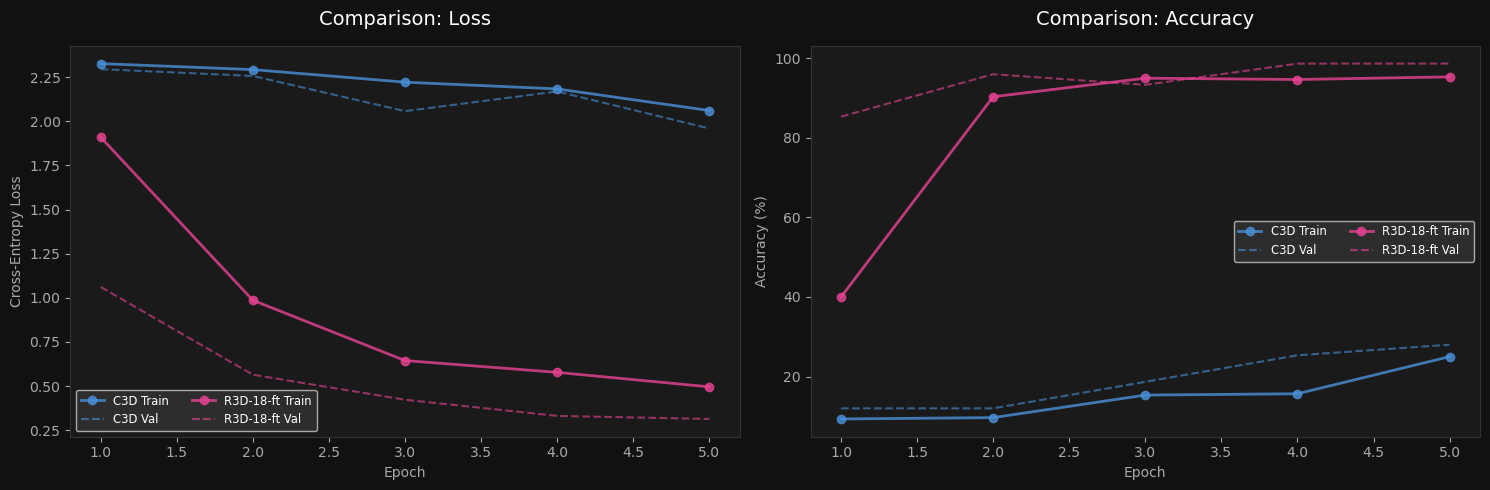

In [38]:
histories = [history_1, history_r3d18ft]
labels = ['C3D', 'R3D-18-ft']
colors = ['#4a90d9', '#e84393'] 

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#111')
min_epochs = min([len(h['train_loss']) for h in histories])
epochs_x = range(1, min_epochs + 1)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.set_facecolor('#1a1a1a')
    
    for i, hist in enumerate(histories):
        tr = hist[f'train_{metric}'][:min_epochs]
        vl = hist[f'val_{metric}'][:min_epochs]
        
        if metric == 'acc':
            tr = [v * 100 for v in tr]
            vl = [v * 100 for v in vl]
        
        ax.plot(epochs_x, tr, 'o-', color=colors[i], label=f'{labels[i]} Train', linewidth=2, alpha=0.8)
        ax.plot(epochs_x, vl, '--', color=colors[i], label=f'{labels[i]} Val', linewidth=1.5, alpha=0.6)

    ax.set_title(f'Comparison: {title}', color='white', fontsize=14, pad=15)
    ax.set_xlabel('Epoch', color='#aaa')
    ax.tick_params(colors='#aaa')
    
    ax.legend(facecolor='#333', labelcolor='white', fontsize='small', ncol=2)
    
    for spine in ax.spines.values(): 
        spine.set_edgecolor('#333')
        
    if metric == 'acc': 
        ax.set_ylabel('Accuracy (%)', color='#aaa')
    else: 
        ax.set_ylabel('Cross-Entropy Loss', color='#aaa')

plt.tight_layout()
plt.show()

R3D-18 with partial fine tuning is performing lot better than C3D.